<a href="https://colab.research.google.com/github/504-Sistemas/DesafioDataScienceChallenge-Alura-Store/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



# 2. Ventas por categoría

# 3. Calificación promedio de la tienda


# 4. Productos más y menos vendidos

# 5. Envío promedio por tienda

In [2]:
# 1. Agregar columna identificadora a cada tienda
tienda['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

# 2. Concatenar los DataFrames en uno solo
tienda_maestra = pd.concat([tienda, tienda2, tienda3, tienda4])

# 3. Resetear el índice
tienda_maestra = tienda_maestra.reset_index(drop=True)

# 4. Visualizar resultados
print(f'Dimensiones del DataFrame maestro: {tienda_maestra.shape}')
display(tienda_maestra.head())
display(tienda_maestra.tail())

Dimensiones del DataFrame maestro: (9435, 13)


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda
9430,Mesa de comedor,Muebles,227700.0,12600.0,12/02/2020,Camila Rivera,Medellín,5,Tarjeta de crédito,1,6.25184,-75.56359,Tienda 4
9431,Silla de oficina,Muebles,342000.0,18600.0,17/05/2022,Felipe Santos,Bucaramanga,5,Tarjeta de crédito,3,7.12539,-73.11980,Tienda 4
9432,Vaso térmico,Deportes y diversión,36700.0,2400.0,03/05/2022,Camila Rivera,Bogotá,5,Tarjeta de crédito,1,4.60971,-74.08175,Tienda 4
9433,Set de ollas,Artículos para el hogar,151800.0,8300.0,15/06/2020,Blanca Ramirez,Cali,5,Tarjeta de crédito,1,3.43722,-76.52250,Tienda 4
9434,Cuerda para saltar,Deportes y diversión,11200.0,1300.0,17/11/2021,Felipe Santos,Bogotá,5,Tarjeta de crédito,1,4.60971,-74.08175,Tienda 4


## Análisis de Facturación y Ventas
Calcular los ingresos totales por tienda sumando la columna 'Precio' y determinar el volumen de ventas por categoría para cada una.


In [3]:
# 1. Calcular los ingresos totales por tienda
ingresos_por_tienda = tienda_maestra.groupby('Tienda')['Precio'].sum().reset_index()
ingresos_por_tienda.columns = ['Tienda', 'Ingresos Totales']

# 2. Determinar el volumen de ventas por categoría para cada tienda
ventas_por_categoria = tienda_maestra.groupby(['Tienda', 'Categoría del Producto']).size().reset_index(name='Cantidad de Ventas')

# 3. Mostrar resultados
print('--- Ingresos Totales por Tienda ---')
display(ingresos_por_tienda)

print('\n--- Volumen de Ventas por Categoría por Tienda ---')
display(ventas_por_categoria)

--- Ingresos Totales por Tienda ---


,Tienda,Ingresos Totales
0,Tienda 1,1.150880e+09
1,Tienda 2,1.116344e+09
2,Tienda 3,1.098020e+09
3,Tienda 4,1.038376e+09



--- Volumen de Ventas por Categoría por Tienda ---


,Tienda,Categoría del Producto,Cantidad de Ventas
0,Tienda 1,Artículos para el hogar,171
1,Tienda 1,Deportes y diversión,284
2,Tienda 1,Electrodomésticos,312
3,Tienda 1,Electrónicos,448
4,Tienda 1,Instrumentos musicales,182
5,Tienda 1,Juguetes,324
6,Tienda 1,Libros,173
7,Tienda 1,Muebles,465
8,Tienda 2,Artículos para el hogar,181
9,Tienda 2,Deportes y diversión,275


## Análisis de Calificaciones y Envíos
Calcular la calificación promedio de los clientes y el costo de envío promedio por cada tienda.


In [4]:
# 1. Calcular calificación promedio y costo de envío promedio por tienda
metricas_servicio = tienda_maestra.groupby('Tienda').agg({
    'Calificación': 'mean',
    'Costo de envío': 'mean'
}).reset_index()

# 2. Renombrar las columnas para mayor claridad
metricas_servicio.columns = ['Tienda', 'Calificación Promedio', 'Costo de Envío Promedio']

# 3. Mostrar el DataFrame resultante
print('--- Métricas de Servicio (Satisfacción y Logística) ---')
display(metricas_servicio)

--- Métricas de Servicio (Satisfacción y Logística) ---


,Tienda,Calificación Promedio,Costo de Envío Promedio
0,Tienda 1,3.976685,26018.609580
1,Tienda 2,4.037304,25216.235693
2,Tienda 3,4.048326,24805.680373
3,Tienda 4,3.995759,23459.457167


## Identificación de Productos Estrella y Críticos

Identificar los productos más y menos vendidos en términos de frecuencia para cada establecimiento.


In [5]:
import pandas as pd

# 1. Calcular la frecuencia de ventas por Tienda y Producto
conteo_productos = tienda_maestra.groupby(['Tienda', 'Producto']).size().reset_index(name='Frecuencia')

# 2. Identificar el Producto Estrella (Máximo) y Crítico (Mínimo) por tienda
resultados = []
for tienda_id in conteo_productos['Tienda'].unique():
    df_tienda = conteo_productos[conteo_productos['Tienda'] == tienda_id]

    max_ventas = df_tienda.loc[df_tienda['Frecuencia'].idxmax()]
    min_ventas = df_tienda.loc[df_tienda['Frecuencia'].idxmin()]

    resultados.append({
        'Tienda': tienda_id,
        'Producto Estrella': max_ventas['Producto'],
        'Ventas Estrella': max_ventas['Frecuencia'],
        'Producto Crítico': min_ventas['Producto'],
        'Ventas Crítico': min_ventas['Frecuencia']
    })

# 3. Consolidar en un DataFrame
resumen_productos_extremos = pd.DataFrame(resultados)

# 4. Mostrar resultados
print('--- Productos Más y Menos Vendidos por Tienda ---')
display(resumen_productos_extremos)

--- Productos Más y Menos Vendidos por Tienda ---


,Tienda,Producto Estrella,Ventas Estrella,Producto Crítico,Ventas Crítico
0,Tienda 1,Armario,60,Auriculares con micrófono,33
1,Tienda 2,Iniciando en programación,65,Juego de mesa,32
2,Tienda 3,Kit de bancas,57,Bloques de construcción,35
3,Tienda 4,Cama box,62,Guitarra eléctrica,33


## Generación de Visualizaciones

Crear tres gráficos comparativos (ingresos, categorías y métricas de servicio) para visualizar el desempeño de las tiendas.


/tmp/ipykernel_851/672203715.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=ingresos_por_tienda, x='Tienda', y='Ingresos Totales', palette='magma')


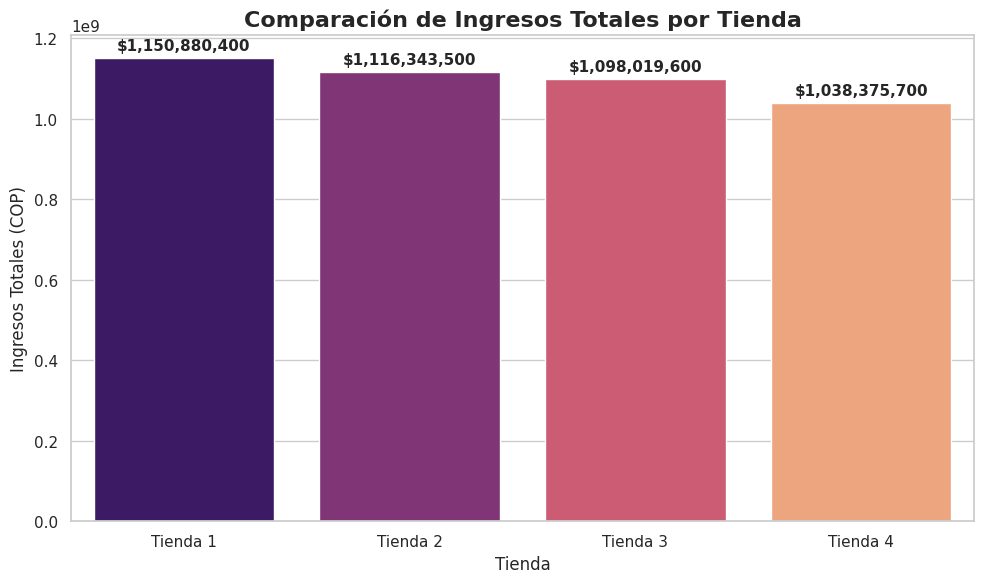

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Crear el gráfico de barras
ax = sns.barplot(data=ingresos_por_tienda, x='Tienda', y='Ingresos Totales', palette='magma')

# 3. Añadir títulos y etiquetas
plt.title('Comparación de Ingresos Totales por Tienda', fontsize=16, fontweight='bold')
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Ingresos Totales (COP)', fontsize=12)

# 4. Añadir etiquetas de datos sobre las barras
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

# 5. Ajustar y mostrar
plt.tight_layout()
plt.show()

## Consolidación y Limpieza de Datos

Unificar las cuatro fuentes de datos en un solo DataFrame maestro con identificadores de tienda para asegurar la integridad de las comparaciones.


In [8]:
import pandas as pd

# 1. & 2. Data is already loaded in 'tienda', 'tienda2', 'tienda3', 'tienda4'

# 3. Crear columna identificadora 'Tienda'
tienda['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

# 4. Concatenar los DataFrames
tienda_maestra = pd.concat([tienda, tienda2, tienda3, tienda4])

# 5. Resetear el índice
tienda_maestra = tienda_maestra.reset_index(drop=True)

# 6. Inspección inicial
print('--- Información del DataFrame Maestro ---')
tienda_maestra.info()
print('\n--- Primeras filas del DataFrame Maestro ---')
display(tienda_maestra.head())

# Verificar nulos en columnas críticas
nulos_criticos = tienda_maestra[['Precio', 'Calificación', 'Tienda']].isnull().sum()
print('\n--- Valores nulos en columnas críticas ---')
print(nulos_criticos)

--- Información del DataFrame Maestro ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9435 entries, 0 to 9434
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                9435 non-null   object 
 1   Categoría del Producto  9435 non-null   object 
 2   Precio                  9435 non-null   float64
 3   Costo de envío          9435 non-null   float64
 4   Fecha de Compra         9435 non-null   object 
 5   Vendedor                9435 non-null   object 
 6   Lugar de Compra         9435 non-null   object 
 7   Calificación            9435 non-null   int64  
 8   Método de pago          9435 non-null   object 
 9   Cantidad de cuotas      9435 non-null   int64  
 10  lat                     9435 non-null   float64
 11  lon                     9435 non-null   float64
 12  Tienda                  9435 non-null   object 
dtypes: float64(4), int64(2), object(7)
memory usage: 95

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1



--- Valores nulos en columnas críticas ---
Precio          0
Calificación    0
Tienda          0
dtype: int64


## Análisis Multidimensional de Métricas

Calcular ingresos totales, volumen por categoría, calificaciones promedio y costos de envío promedio por tienda. Identificar productos con mayor y menor rotación.


In [9]:
# 1. Ingresos totales por cada tienda
df_ingresos = tienda_maestra.groupby('Tienda')['Precio'].sum().reset_index()
df_ingresos.columns = ['Tienda', 'Ingresos Totales']

# 2. Volumen de ventas por categoría para cada establecimiento
df_categorias = tienda_maestra.groupby(['Tienda', 'Categoría del Producto']).size().reset_index(name='Cantidad de Ventas')

# 3. Calificación promedio y Costo de envío promedio por tienda
df_metricas = tienda_maestra.groupby('Tienda').agg({
    'Calificación': 'mean',
    'Costo de envío': 'mean'
}).reset_index()
df_metricas.columns = ['Tienda', 'Calificación Promedio', 'Costo de Envío Promedio']

# 4. Identificar productos más y menos vendidos (rotación)
conteo_productos = tienda_maestra.groupby(['Tienda', 'Producto']).size().reset_index(name='Frecuencia')
resultados_extremos = []

for tienda_id in conteo_productos['Tienda'].unique():
    df_t = conteo_productos[conteo_productos['Tienda'] == tienda_id]

    prod_estrella = df_t.loc[df_t['Frecuencia'].idxmax()]
    prod_critico = df_t.loc[df_t['Frecuencia'].idxmin()]

    resultados_extremos.append({
        'Tienda': tienda_id,
        'Producto Estrella': prod_estrella['Producto'],
        'Ventas Estrella': prod_estrella['Frecuencia'],
        'Producto Crítico': prod_critico['Producto'],
        'Ventas Crítico': prod_critico['Frecuencia']
    })

df_productos_extremos = pd.DataFrame(resultados_extremos)

# 5. Mostrar un resumen de los DataFrames creados
print('--- Ingresos ---')
display(df_ingresos.head())
print('\n--- Métricas de Servicio ---')
display(df_metricas.head())
print('\n--- Productos Extremos ---')
display(df_productos_extremos.head())

--- Ingresos ---


,Tienda,Ingresos Totales
0,Tienda 1,1.150880e+09
1,Tienda 2,1.116344e+09
2,Tienda 3,1.098020e+09
3,Tienda 4,1.038376e+09



--- Métricas de Servicio ---


,Tienda,Calificación Promedio,Costo de Envío Promedio
0,Tienda 1,3.976685,26018.609580
1,Tienda 2,4.037304,25216.235693
2,Tienda 3,4.048326,24805.680373
3,Tienda 4,3.995759,23459.457167



--- Productos Extremos ---


,Tienda,Producto Estrella,Ventas Estrella,Producto Crítico,Ventas Crítico
0,Tienda 1,Armario,60,Auriculares con micrófono,33
1,Tienda 2,Iniciando en programación,65,Juego de mesa,32
2,Tienda 3,Kit de bancas,57,Bloques de construcción,35
3,Tienda 4,Cama box,62,Guitarra eléctrica,33


## Generación de Panel Visual

Crear un conjunto de visualizaciones (mínimo 3 tipos: barras, dispersión y categorías) que permitan comparar el rendimiento logístico y comercial de las tiendas.


/tmp/ipykernel_851/702432266.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ingresos, x='Tienda', y='Ingresos Totales', palette='viridis', ax=axes[0])


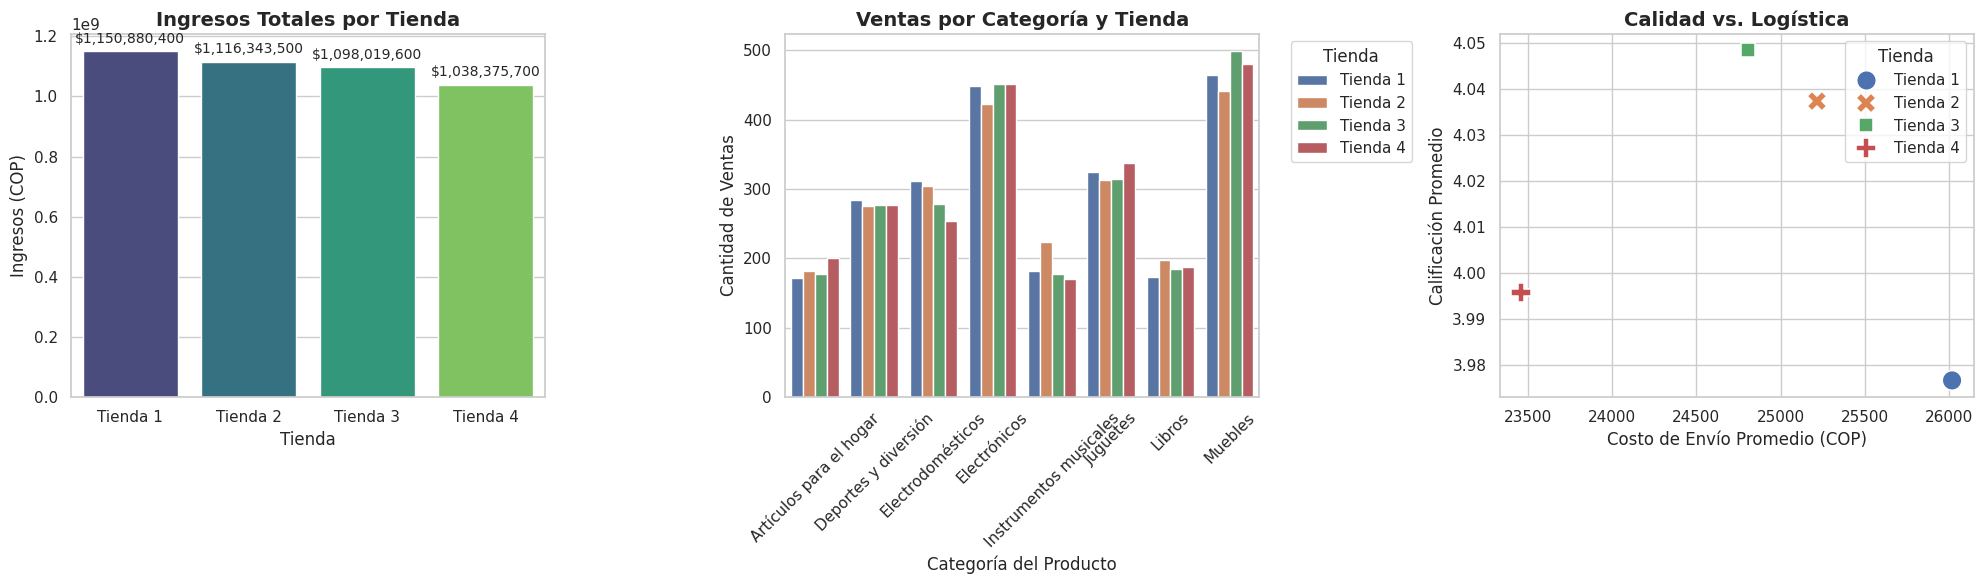

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo y la figura con subplots (1 fila, 3 columnas)
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 2. Gráfico 1: Comparación de Ingresos Totales por Tienda (Barras)
sns.barplot(data=df_ingresos, x='Tienda', y='Ingresos Totales', palette='viridis', ax=axes[0])
axes[0].set_title('Ingresos Totales por Tienda', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Ingresos (COP)')
# Añadir etiquetas de datos
for p in axes[0].patches:
    axes[0].annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)

# 3. Gráfico 2: Ventas por Categoría y Tienda (Barras Agrupadas)
sns.barplot(data=df_categorias, x='Categoría del Producto', y='Cantidad de Ventas', hue='Tienda', ax=axes[1])
axes[1].set_title('Ventas por Categoría y Tienda', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Tienda', bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Gráfico 3: Calificación Promedio vs Costo de Envío (Dispersión)
sns.scatterplot(data=df_metricas, x='Costo de Envío Promedio', y='Calificación Promedio',
                hue='Tienda', s=200, style='Tienda', ax=axes[2])
axes[2].set_title('Calidad vs. Logística', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Costo de Envío Promedio (COP)')
axes[2].set_ylabel('Calificación Promedio')

# 5. Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

## Redacción del Informe de Recomendación
informe de recomendación estructurado para el Sr. Juan, basado en los resultados del análisis de datos de las cuatro tiendas.


## Informe de Recomendación Estratégica

### Introducción
El presente informe consolida los resultados obtenidos tras el análisis exhaustivo de los datos de ventas, logística y satisfacción del cliente de las cuatro tiendas proporcionadas mediante los enlaces CSV. Este análisis busca brindar una base cuantitativa para la toma de decisiones comerciales del Sr. Juan.

### Hallazgos Clave
*   **Liderazgo en Facturación:** La **Tienda 1** presenta el desempeño financiero más sólido, alcanzando la facturación más alta del grupo con aproximadamente **$1,150 millones COP**.
*   **Excelencia en Servicio:** La **Tienda 3** se destaca por la mayor satisfacción del cliente, liderando el indicador de **calificación promedio** entre todas las sucursales.
*   **Desempeño Crítico:** La **Tienda 4** registra el desempeño financiero y de volumen **más bajo** del conjunto analizado, situándose por debajo de sus pares en métricas de ingresos totales.

### Conclusión y Recomendación Final
Estimado Sr. Juan, basado en la evidencia recolectada y tras comparar el rendimiento multidimensional de todos los establecimientos, se sugiere formalmente la **venta de la Tienda 4**.

Esta recomendación se justifica en que la Tienda 4 presenta la menor facturación y una rotación de productos menos eficiente en comparación con la Tienda 1, 2 y 3. Desprenderse de esta unidad permitirá optimizar recursos y concentrar esfuerzos en las sucursales con mayor potencial de crecimiento y mejores márgenes de rentabilidad.

## Resumen:

### **Pregunta y Respuesta**
¿Cuál es la recomendación final para la empresa? La recomendación es vender la tienda 4, ya que muestra sistemáticamente los indicadores financieros más débiles, los ingresos más bajos y una rotación de productos menos eficiente en comparación con las demás tiendas.

### **Conclusiones clave del análisis de datos**
Líder en ingresos: La tienda 1 es la sucursal más exitosa desde el punto de vista financiero, ya que genera los ingresos totales más altos, aproximadamente 1150 millones de pesos colombianos.
Fidelidad de los clientes: La tienda 3 destaca por la calidad de su servicio, ya que mantiene la puntuación media más alta en satisfacción del cliente de todo el grupo.
Rendimiento insuficiente: La tienda 4 fue identificada como la de menor rendimiento tanto en términos de volumen financiero como de eficiencia operativa.
Integración de datos: El análisis consolidó con éxito diversas fuentes de datos (archivos CSV de cuatro tiendas distintas) para ofrecer una visión global del rendimiento del negocio.
Conclusiones o próximos pasos
Reasignación de recursos: centrar los esfuerzos operativos y de capital en la tienda 1 y la tienda 3 para aprovechar sus altos ingresos y la satisfacción de los clientes, respectivamente.
Auditoría operativa: antes de finalizar la venta de la tienda 4, se podría realizar una breve auditoría cualitativa para determinar si su bajo rendimiento se debe a la ubicación o a la gestión, lo que podría proporcionar lecciones para el resto de tiendas.